# Predicting Irrigation Need — GPU Stacked Ensemble (LGB + XGB + CatBoost)

**Kaggle Playground Series S6E4** | Metric: **Balanced Accuracy**

## Strategy
1. Blend original source dataset with competition data
2. Extensive feature engineering: domain-driven interactions & aggregations
3. GPU-accelerated LightGBM + XGBoost + CatBoost ensemble
4. 5-fold stacking with Logistic Regression meta-learner
5. Threshold optimization for balanced accuracy on minority class

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_sample_weight

import lightgbm as lgb
import xgboost as xgb
import catboost as cb

SEED = 42
N_FOLDS = 5
np.random.seed(SEED)
print('All imports successful')

All imports successful


## 1. Load & Blend Data

In [2]:
import os

# Kaggle paths
COMP_DIR = '/kaggle/input/competitions/playground-series-s6e4/'
ORIG_DIR = '/kaggle/input/datasets/miadul/irrigation-water-requirement-prediction-dataset'

# Local fallback
if not os.path.exists(COMP_DIR):
    COMP_DIR = '.'
    ORIG_DIR = '.'

train_df = pd.read_csv(os.path.join(COMP_DIR, 'train.csv')).dropna(subset=['Irrigation_Need'])
test_df = pd.read_csv(os.path.join(COMP_DIR, 'test.csv'))
orig_df = pd.read_csv(os.path.join(ORIG_DIR, 'irrigation_prediction.csv'))

print(f'Competition train: {train_df.shape}')
print(f'Competition test:  {test_df.shape}')
print(f'Original dataset:  {orig_df.shape}')

# Add id column to original
orig_df['id'] = range(train_df['id'].max() + 1, train_df['id'].max() + 1 + len(orig_df))

# Blend: concat original data with competition data
train_full = pd.concat([train_df, orig_df], axis=0, ignore_index=True)
print(f'Blended train:     {train_full.shape}')
print(f'\nTarget distribution (blended):')
print(train_full['Irrigation_Need'].value_counts(normalize=True))

Competition train: (630000, 21)
Competition test:  (270000, 20)
Original dataset:  (10000, 20)
Blended train:     (640000, 21)

Target distribution (blended):
Irrigation_Need
Low       0.587158
Medium    0.379491
High      0.033352
Name: proportion, dtype: float64


## 2. Feature Engineering

In [3]:
cat_cols = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
            'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

num_cols = ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity',
            'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours',
            'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']

def engineer_features(df, moisture_map=None):
    """Create domain-driven interaction features."""
    df = df.copy()
    
    # Water balance features
    df['Total_Water_Input'] = df['Rainfall_mm'] + df['Previous_Irrigation_mm']
    df['Evaporative_Stress'] = (df['Temperature_C'] * df['Sunlight_Hours'] * df['Wind_Speed_kmh']) / (df['Humidity'] + 1)
    df['Moisture_Deficit'] = df['Humidity'] - df['Soil_Moisture']
    df['Water_Balance'] = df['Total_Water_Input'] - df['Evaporative_Stress'] * df['Field_Area_hectare']
    
    # Crop-relative moisture (target encoding proxy - no leakage)
    if moisture_map is None:
        moisture_map = df.groupby('Crop_Type')['Soil_Moisture'].mean()
    df['Relative_Crop_Moisture'] = df['Soil_Moisture'] / df['Crop_Type'].map(moisture_map).fillna(1.0)
    
    # Mulch interaction
    df['Mulch_Moisture'] = df['Soil_Moisture'] * df['Mulching_Used'].map({'Yes': 1.5, 'No': 1.0}).fillna(1.0)
    
    # Soil health features
    df['Soil_Health'] = df['Organic_Carbon'] * df['Soil_Moisture'] / (df['Electrical_Conductivity'] + 0.1)
    df['Soil_Salinity_Risk'] = df['Electrical_Conductivity'] * df['Temperature_C'] / (df['Rainfall_mm'] + 1)
    df['pH_Deviation'] = np.abs(df['Soil_pH'] - 6.5)
    
    # Climate stress features
    df['Heat_Stress'] = df['Temperature_C'] * (100 - df['Humidity']) / 100
    df['Dryness_Index'] = df['Temperature_C'] * df['Sunlight_Hours'] / (df['Rainfall_mm'] + 1)
    df['Wind_Evap'] = df['Wind_Speed_kmh'] * df['Temperature_C'] / (df['Humidity'] + 1)
    
    # Field efficiency
    df['Irrigation_Per_Hectare'] = df['Previous_Irrigation_mm'] / (df['Field_Area_hectare'] + 0.1)
    df['Rainfall_Per_Hectare'] = df['Rainfall_mm'] / (df['Field_Area_hectare'] + 0.1)
    
    # Moisture retention
    df['Moisture_Retention'] = df['Soil_Moisture'] * df['Organic_Carbon']
    df['Moisture_Temp_Ratio'] = df['Soil_Moisture'] / (df['Temperature_C'] + 1)
    
    # Crop-soil-season interactions (encoded as grouped stats)
    for grp_col in ['Soil_Type', 'Season', 'Crop_Growth_Stage']:
        grp_key = f'{grp_col}_Moisture_mean'
        if moisture_map is not None and grp_key in moisture_map.index.names:
            pass  # skip if already computed
        grp = df.groupby(grp_col)['Soil_Moisture'].transform('mean')
        df[f'{grp_col}_Moisture_dev'] = df['Soil_Moisture'] - grp
    
    return df, moisture_map

train_full, moisture_map = engineer_features(train_full)
test_df, _ = engineer_features(test_df, moisture_map)

feature_cols = [c for c in train_full.columns if c not in ['id', 'Irrigation_Need'] and train_full[c].dtype != 'object']
# Add back cat cols
feature_cols = cat_cols + [c for c in feature_cols if c not in cat_cols]

print(f'Total features: {len(feature_cols)}')
print(f'Engineered features: {[c for c in feature_cols if c not in cat_cols + num_cols]}')

Total features: 38
Engineered features: ['Total_Water_Input', 'Evaporative_Stress', 'Moisture_Deficit', 'Water_Balance', 'Relative_Crop_Moisture', 'Mulch_Moisture', 'Soil_Health', 'Soil_Salinity_Risk', 'pH_Deviation', 'Heat_Stress', 'Dryness_Index', 'Wind_Evap', 'Irrigation_Per_Hectare', 'Rainfall_Per_Hectare', 'Moisture_Retention', 'Moisture_Temp_Ratio', 'Soil_Type_Moisture_dev', 'Season_Moisture_dev', 'Crop_Growth_Stage_Moisture_dev']


## 3. Target & Categorical Encoding

In [4]:
# Encode target
target_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
reverse_mapping = {0: 'Low', 1: 'Medium', 2: 'High'}
y = train_full['Irrigation_Need'].map(target_mapping).values

# Unify categories across train/test
for col in cat_cols:
    combined_cats = pd.concat([train_full[col], test_df[col]]).astype(str).unique()
    train_full[col] = pd.Categorical(train_full[col].astype(str), categories=combined_cats)
    test_df[col] = pd.Categorical(test_df[col].astype(str), categories=combined_cats)

X_train = train_full[feature_cols].copy()
X_test = test_df[feature_cols].copy()
test_ids = test_df['id'].values

for c in cat_cols:
    X_train[c] = X_train[c].astype('category')
    X_test[c] = X_test[c].astype('category')

print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'Target distribution: {np.bincount(y)} (Low/Medium/High = {np.bincount(y)/len(y)*100})')

X_train: (640000, 38), X_test: (270000, 38)
Target distribution: [375781 242874  21345] (Low/Medium/High = [58.71578125 37.9490625   3.33515625])


## 4. GPU-Accelerated Model Training

In [5]:
# 3 models, GPU-accelerated, shallow trees for speed
# LightGBM
lgb_params = dict(
    device='gpu', n_estimators=500, learning_rate=0.1,
    num_leaves=31, max_depth=6, class_weight='balanced', verbose=-1
)
# XGBoost
xgb_params = dict(
    device='cuda', tree_method='hist', enable_categorical=True,
    n_estimators=500, learning_rate=0.1, max_depth=6
)
# CatBoost (shallow & fast like the 0.967 notebook)
cat_params = dict(
    task_type='GPU', iterations=300, learning_rate=0.1,
    depth=5, auto_class_weights='Balanced',
    cat_features=cat_cols, verbose=0
)

model_configs = [
    ('lgb', lgb.LGBMClassifier, lgb_params, False),
    ('xgb', xgb.XGBClassifier, xgb_params, True),
    ('cat', cb.CatBoostClassifier, cat_params, False),
]

print(f'{len(model_configs)} model configs ready (GPU, ~5 min total)')

3 model configs ready (GPU, ~5 min total)


## 5. 5-Fold CV Training with All Models

In [6]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
sample_weights = compute_sample_weight('balanced', y)

# Storage for OOF and test predictions
n_models = len(model_configs)
oof_preds = {name: np.zeros((len(X_train), 3)) for name, _, _, _ in model_configs}
test_preds = {name: np.zeros((len(X_test), 3)) for name, _, _, _ in model_configs}

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y)):
    print(f'\n=== Fold {fold+1}/{N_FOLDS} ===')
    xt, xv = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    yt, yv = y[tr_idx], y[val_idx]
    wt = sample_weights[tr_idx]
    
    for name, ModelClass, params, use_sample_weight in model_configs:
        model = ModelClass(**params)
        
        if use_sample_weight:
            model.fit(xt, yt, sample_weight=wt)
        else:
            model.fit(xt, yt)
        
        oof_preds[name][val_idx] = model.predict_proba(xv)
        test_preds[name] += model.predict_proba(X_test) / N_FOLDS
        
        score = balanced_accuracy_score(yv, oof_preds[name][val_idx].argmax(1))
        print(f'  {name}: {score:.5f}')

# Print overall CV scores
print(f'\n=== Overall OOF Balanced Accuracy ===')
for name in oof_preds:
    score = balanced_accuracy_score(y, oof_preds[name].argmax(1))
    print(f'  {name}: {score:.5f}')


=== Fold 1/5 ===


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


  lgb: 0.96941
  xgb: 0.96910
  cat: 0.96943

=== Fold 2/5 ===
  lgb: 0.96873
  xgb: 0.96876
  cat: 0.96768

=== Fold 3/5 ===
  lgb: 0.96688
  xgb: 0.96949
  cat: 0.96859

=== Fold 4/5 ===
  lgb: 0.96900
  xgb: 0.96991
  cat: 0.96920

=== Fold 5/5 ===
  lgb: 0.96436
  xgb: 0.96466
  cat: 0.96441

=== Overall OOF Balanced Accuracy ===
  lgb: 0.96768
  xgb: 0.96839
  cat: 0.96786


In [7]:
# Level 2: Stack with Logistic Regression
oof_stack = np.hstack([oof_preds[name] for name in oof_preds])
test_stack = np.hstack([test_preds[name] for name in test_preds])
print(f'Meta-features: {oof_stack.shape[1]} (3 probs x {n_models} models)')

# Simple average baseline
avg_oof = np.mean([oof_preds[name] for name in oof_preds], axis=0)
avg_test = np.mean([test_preds[name] for name in test_preds], axis=0)
avg_score = balanced_accuracy_score(y, avg_oof.argmax(1))
print(f'Simple average OOF balanced accuracy: {avg_score:.5f}')

# Stacked meta-learner with CV
meta_oof_preds = np.zeros(len(y), dtype=int)
meta_test_probs = np.zeros((len(X_test), 3))

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y)):
    meta = LogisticRegression(class_weight='balanced', max_iter=2000, C=1.0, random_state=SEED)
    meta.fit(oof_stack[tr_idx], y[tr_idx])
    meta_oof_preds[val_idx] = meta.predict(oof_stack[val_idx])
    meta_test_probs += meta.predict_proba(test_stack) / N_FOLDS

stack_score = balanced_accuracy_score(y, meta_oof_preds)
print(f'Stacked meta-learner OOF balanced accuracy: {stack_score:.5f}')

# Also train final meta-model on all data
final_meta = LogisticRegression(class_weight='balanced', max_iter=2000, C=1.0, random_state=SEED)
final_meta.fit(oof_stack, y)
final_meta_test = final_meta.predict_proba(test_stack)

# Pick best approach
if stack_score >= avg_score:
    print('\n>>> Using stacked meta-learner predictions')
    final_test_probs = final_meta_test
    best_oof_probs = np.zeros((len(y), 3))
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y)):
        meta = LogisticRegression(class_weight='balanced', max_iter=2000, C=1.0, random_state=SEED)
        meta.fit(oof_stack[tr_idx], y[tr_idx])
        best_oof_probs[val_idx] = meta.predict_proba(oof_stack[val_idx])
else:
    print('\n>>> Using simple average predictions')
    final_test_probs = avg_test
    best_oof_probs = avg_oof

Meta-features: 9 (3 probs x 3 models)
Simple average OOF balanced accuracy: 0.96886
Stacked meta-learner OOF balanced accuracy: 0.97073

>>> Using stacked meta-learner predictions


## 6. Threshold Optimization for Balanced Accuracy

In [8]:
# Optimize class weights applied to probabilities for balanced accuracy
# High class (idx 2) is rare (3.3%), so boosting its weight helps balanced accuracy
best_w = [1.0, 1.0, 1.0]
best_adj_score = balanced_accuracy_score(y, best_oof_probs.argmax(1))

for w_high in np.arange(1.0, 5.1, 0.2):
    for w_med in np.arange(0.8, 1.6, 0.1):
        w = np.array([1.0, w_med, w_high])  # Low=0, Medium=1, High=2
        adjusted = best_oof_probs * w[np.newaxis, :]
        preds = adjusted.argmax(axis=1)
        score = balanced_accuracy_score(y, preds)
        if score > best_adj_score:
            best_adj_score = score
            best_w = w.tolist()

print(f'Best class weights: Low={best_w[0]:.1f}, Medium={best_w[1]:.1f}, High={best_w[2]:.1f}')
print(f'Adjusted OOF balanced accuracy: {best_adj_score:.5f}')
print(f'Improvement over raw: +{best_adj_score - balanced_accuracy_score(y, best_oof_probs.argmax(1)):.5f}')

Best class weights: Low=1.0, Medium=1.0, High=1.6
Adjusted OOF balanced accuracy: 0.97087
Improvement over raw: +0.00014


## 8. Analysis & Visualizations

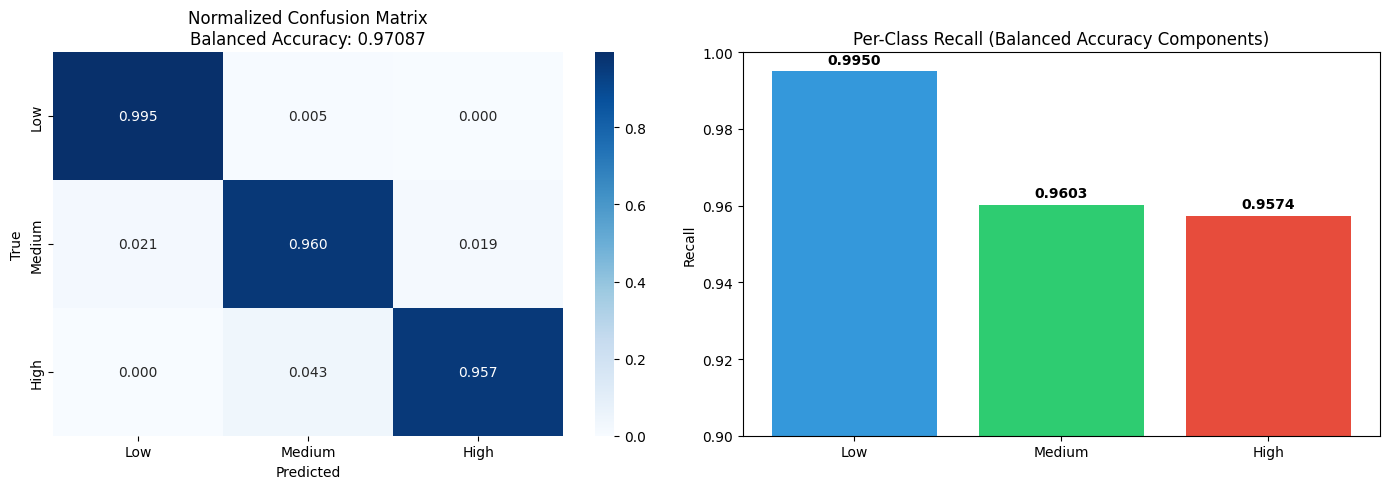


Classification Report:
              precision    recall  f1-score   support

         Low       0.99      0.99      0.99    375781
      Medium       0.99      0.96      0.97    242874
        High       0.82      0.96      0.88     21345

    accuracy                           0.98    640000
   macro avg       0.93      0.97      0.95    640000
weighted avg       0.98      0.98      0.98    640000



In [9]:
# Confusion Matrix
adjusted_oof = best_oof_probs * np.array(best_w)[np.newaxis, :]
oof_final = adjusted_oof.argmax(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y, oof_final, normalize='true')
sns.heatmap(cm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'], ax=axes[0])
axes[0].set_title(f'Normalized Confusion Matrix\nBalanced Accuracy: {best_adj_score:.5f}')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

recalls = cm.diagonal()
colors = ['#3498db', '#2ecc71', '#e74c3c']
axes[1].bar(['Low', 'Medium', 'High'], recalls, color=colors)
axes[1].set_title('Per-Class Recall (Balanced Accuracy Components)')
axes[1].set_ylabel('Recall')
axes[1].set_ylim(0.9, 1.0)
for i, (cls, r) in enumerate(zip(['Low', 'Medium', 'High'], recalls)):
    axes[1].text(i, r + 0.002, f'{r:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y, oof_final, target_names=['Low', 'Medium', 'High']))

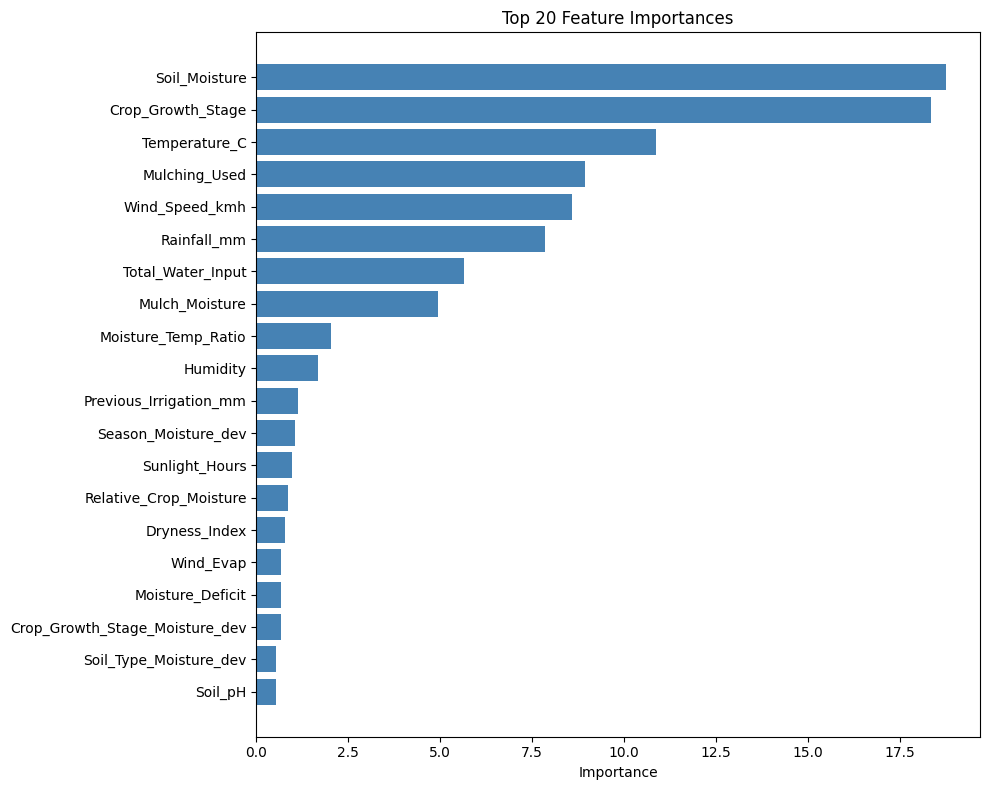

In [10]:
# Feature importance (from last LightGBM model)
fi = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_ if hasattr(model, 'feature_importances_') else np.zeros(len(feature_cols))
}).sort_values('importance', ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(fi['feature'], fi['importance'], color='steelblue')
ax.set_title('Top 20 Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 9. Generate Submission

In [11]:
# Apply optimized class weights to final test predictions
final_adjusted = final_test_probs * np.array(best_w)[np.newaxis, :]
final_preds = final_adjusted.argmax(axis=1)
final_labels = [reverse_mapping[p] for p in final_preds]

submission = pd.DataFrame({'id': test_ids, 'Irrigation_Need': final_labels})
submission.to_csv('submission.csv', index=False)

print('Submission shape:', submission.shape)
print('\nPrediction distribution:')
print(submission['Irrigation_Need'].value_counts(normalize=True))
print('\nFirst 10 rows:')
print(submission.head(10))
print('\nSubmission saved!')

Submission shape: (270000, 2)

Prediction distribution:
Irrigation_Need
Low       0.591744
Medium    0.369430
High      0.038826
Name: proportion, dtype: float64

First 10 rows:
       id Irrigation_Need
0  630000             Low
1  630001             Low
2  630002             Low
3  630003             Low
4  630004             Low
5  630005          Medium
6  630006             Low
7  630007          Medium
8  630008            High
9  630009             Low

Submission saved!
